# MAE 6246 — Homework 1: Linearization of a Two-Tank System

## Submission format

Submit the completed IPYNB file through Blackboard. You may enter the analytical work in the designated Markdown response cells using LaTeX or clearly formatted algebra. If you are not familiar with LaTeX, you may instead write the analytical work on paper and submit it as a PDF file in addition to the IPYNB file. In that case, write "submitted separately as a PDF" in each corresponding response cell.

Finding the equilibrium and deriving the linearization are analytical exercises: do not use SymPy, automatic differentiation, finite differences, or a numerical Jacobian for those parts. Python may be used beginning with the eigenvalue calculations.

Before submitting, restart the kernel and run all cells from top to bottom. Keep all generated figures and numerical output in the notebook.

## Motivation: regulating liquid levels

Coupled tanks are used in water treatment, chemical processing, thermal-management loops, and storage systems. A pump supplies the upper tank. Liquid drains from the upper tank into the lower tank and then leaves the lower tank. The measured output is the lower-tank level.

The square-root flow law is a simplified form of Torricelli's law. It makes this a nonlinear system even though the equipment is simple. A local linear model is useful for predicting transients and, later in the course, for designing feedback controllers and state estimators.

This assignment asks three practical questions:

1. At what levels can the tanks operate steadily?
2. What do the eigenvalues and eigenvectors say about the transient response?
3. How far can the state move before the local linear model becomes inaccurate?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
from scipy.integrate import solve_ivp

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})

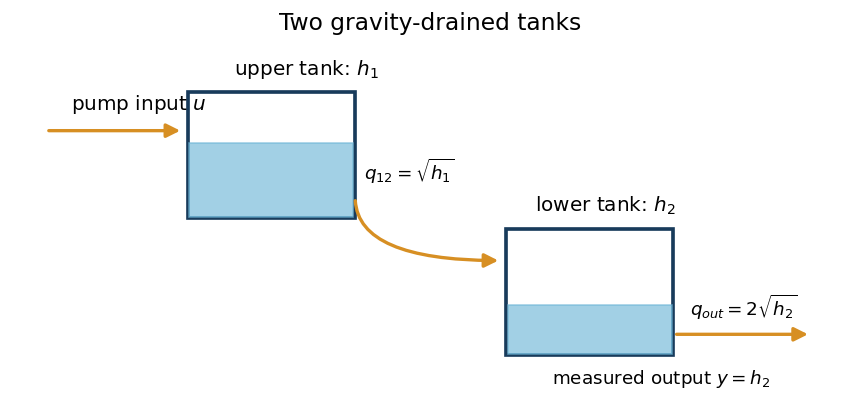

In [2]:
# Supplied system schematic — no student code is required in this cell.
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 5)
ax.axis("off")

tank_color = "#183b5b"
water_color = "#70b7d7"
flow_color = "#d78f23"

ax.add_patch(Rectangle((2.1, 2.5), 2.0, 1.8, fill=False, lw=2.2, ec=tank_color))
ax.add_patch(Rectangle((2.12, 2.52), 1.96, 1.05, color=water_color, alpha=0.65))
ax.add_patch(Rectangle((5.9, 0.55), 2.0, 1.8, fill=False, lw=2.2, ec=tank_color))
ax.add_patch(Rectangle((5.92, 0.57), 1.96, 0.70, color=water_color, alpha=0.65))

arrow_kw = dict(arrowstyle="-|>", mutation_scale=17, lw=2.0, color=flow_color)
ax.add_patch(FancyArrowPatch((0.4, 3.75), (2.05, 3.75), **arrow_kw))
ax.add_patch(FancyArrowPatch((4.1, 2.8), (5.85, 1.9), connectionstyle="angle3", **arrow_kw))
ax.add_patch(FancyArrowPatch((7.9, 0.85), (9.55, 0.85), **arrow_kw))

ax.text(0.7, 4.05, r"pump input $u$", fontsize=12)
ax.text(2.65, 4.55, r"upper tank: $h_1$", fontsize=12)
ax.text(4.2, 3.05, r"$q_{12}=\sqrt{h_1}$", fontsize=11)
ax.text(6.25, 2.6, r"lower tank: $h_2$", fontsize=12)
ax.text(8.1, 1.12, r"$q_{out}=2\sqrt{h_2}$", fontsize=11)
ax.text(6.45, 0.15, r"measured output $y=h_2$", fontsize=11)
ax.set_title("Two gravity-drained tanks", fontsize=14, pad=8)
plt.show()

## Model and operating condition

Use the supplied state

$$x=\begin{bmatrix}h_1\\h_2\end{bmatrix},$$

where $h_1$ and $h_2$ are nondimensional liquid levels. The nonlinear model is

$$
\dot h_1=u-\sqrt{h_1},\qquad
\dot h_2=\sqrt{h_1}-2\sqrt{h_2},\qquad
y=h_2.
$$

Assume $h_1,h_2\ge 0$ and $u\ge 0$. The nominal pump input is $u^\star=1$.



## Part 1 — Nonlinear state-space form (15 points)

Using the supplied state $x=[h_1,\ h_2]^T$, reorganize the nonlinear equations of motion into the vector state-space form

$$
\dot x=f(t,x,u),\qquad y=g(t,x,u).
$$

Write $f(t,x,u)$ and $g(t,x,u)$ explicitly. State whether this particular system depends explicitly on time $t$.

### Analytical response

Replace this text with your state-space model. You may use LaTeX or clearly formatted algebra. If you submit handwritten work as a separate PDF, write "submitted separately as a PDF" here.

## Part 2 — Equilibrium calculation (15 points)

Find the physical equilibrium $x^\star$ corresponding to $u^\star=1$. Show the algebra by setting both state derivatives equal to zero. Explain briefly why the physical equilibrium is unique for this fixed positive input.

### Analytical response

Replace this text with your derivation. You may use LaTeX or clearly formatted algebra. If you submit handwritten work as a separate PDF, write "submitted separately as a PDF" here.

## Part 3 — Analytical linearization (25 points)

Using the following perturbation,

$$\delta x=x-x^\star,\qquad \delta u=u-u^\star,\qquad \delta y=y-y^\star,$$

derive the  matrices for the linearized equation of motion:
$$
A=\left.\frac{\partial f}{\partial x}\right|_{(x^\star,u^\star)},\quad
B=\left.\frac{\partial f}{\partial u}\right|_{(x^\star,u^\star)},\quad
C=\left.\frac{\partial g}{\partial x}\right|_{(x^\star,u^\star)},\quad
D=\left.\frac{\partial g}{\partial u}\right|_{(x^\star,u^\star)}.
$$

Evaluate $A$, $B$, $C$, and $D$ at the equilibrium from Part 2 and state the resulting perturbation model

$$\delta\dot x=A\delta x+B\delta u,\qquad \delta y=C\delta x+D\delta u.$$

Here the correct value of the state matrix is

$$
A=\begin{bmatrix}
-\tfrac{1}{2} & 0\\
\tfrac{1}{2} & -2
\end{bmatrix}.
$$

Verify this value from your analytical Jacobian calculation. Do not compute the Jacobian with Python.

### Analytical response

Replace this text with your derivation and verification. You may use LaTeX or clearly formatted algebra. If you submit handwritten work as a separate PDF, write "submitted separately as a PDF" here.

## Part 4 — Eigenvalues, eigenvectors, and diagonalization (15 points)

Use the matrix $A$ supplied in Part 3. With NumPy:

1. compute the eigenvalues and right eigenvectors of $A$;
2. form $P$ from the eigenvectors and compute $J=P^{-1}AP$; and
3. check whether $J$ is diagonal.

Small roundoff-level off-diagonal entries in $J$ are expected. The scaling and signs of your eigenvectors may differ from another valid answer.

In [7]:
A = np.array([
    [-0.5, 0.0],
    [ 0.5, -2.0],
])

# Compute the eigendecomposition, form J = P^{-1} A P,
# and check whether J is diagonal.
# YOUR CODE HERE
eigenvalues, eigenvectors = np.linalg.eig(A)
print("Eigenvalues:\n", eigenvalues)
print("Eigenvectors (columns):\n", eigenvectors)

P = eigenvectors
J = np.linalg.inv(P) @ A @ P
print(J)

is_diag = np.allclose(J, np.diag(np.diagonal(J)))
print("Is J diagonal", is_diag)

Eigenvalues:
 [-2.  -0.5]
Eigenvectors (columns):
 [[0.         0.9486833 ]
 [1.         0.31622777]]
[[-2.   0. ]
 [ 0.  -0.5]]
Is J diagonal True


## Part 5 — Nonlinear and linear simulations in physical coordinates (25 points)

Implement and integrate both models:

- nonlinear: $\dot x=f(x,u)$;
- linearized: $\delta\dot x=A\delta x+B\delta u$, with $x_L=x^\star+\delta x$.

**Use the original state coordinates in the linear simulation. Do not simulate the diagonalized/modal equation from Part 4.**

Compare the models for the following cases over $0\le t\le10$:

| Case | Initial state $x(0)$ | Input | Purpose |
|---|---:|---:|---|
| A | $x^\star+[0.10,\ 0.02]^T$ | $u(t)=1$ | small initial perturbation |
| B | $[2.00,\ 0.70]^T$ | $u(t)=1$ | larger initial perturbation |
| C | $x^\star$ | $u(t)=1.2$ for $t\ge0$ | pump step |

For each case, place $h_1(t)$ and $h_2(t)$ in separate panels. Overlay nonlinear responses as solid lines and linear predictions as dashed lines. Label every axis and include a legend.

In [8]:
# Enter the equilibrium and input/output matrices from Parts 2 and 3.
x_star = np.array([1.0, 0.25])
u_star = 1.0
B = np.array([[1.0], [0.0]])
C = np.array([[0.0, 1.0]])   # y = h2, per the stated output equation
D = np.array([[0.0]])

def tank_rhs(t, x, input_function):
    h1, h2 = x
    u = input_function(t)
    h1c, h2c = max(h1, 0.0), max(h2, 0.0)
    dh1 = u - np.sqrt(h1c)
    dh2 = np.sqrt(h1c) - 2.0 * np.sqrt(h2c)
    return [dh1, dh2]

def linear_rhs(t, delta_x, input_function):
    delta_u = input_function(t) - u_star
    return (A @ np.array(delta_x) + B.flatten() * delta_u).tolist()

In [9]:
def simulate_pair(x0, input_function, t_final=10.0, samples=1001):
    """Return time, nonlinear state, and linear prediction in physical coordinates."""
    t_eval = np.linspace(0.0, t_final, samples)
    delta_x0 = np.asarray(x0, dtype=float) - x_star

    sol_nl = solve_ivp(
        tank_rhs, (0.0, t_final), np.asarray(x0, dtype=float),
        args=(input_function,), t_eval=t_eval,
        method="RK45", rtol=1e-8, atol=1e-10,
    )
    sol_lin = solve_ivp(
        linear_rhs, (0.0, t_final), delta_x0,
        args=(input_function,), t_eval=t_eval,
        method="RK45", rtol=1e-8, atol=1e-10,
    )

    x_linear_physical = sol_lin.y + x_star[:, None]

    return t_eval, sol_nl.y, x_linear_physical


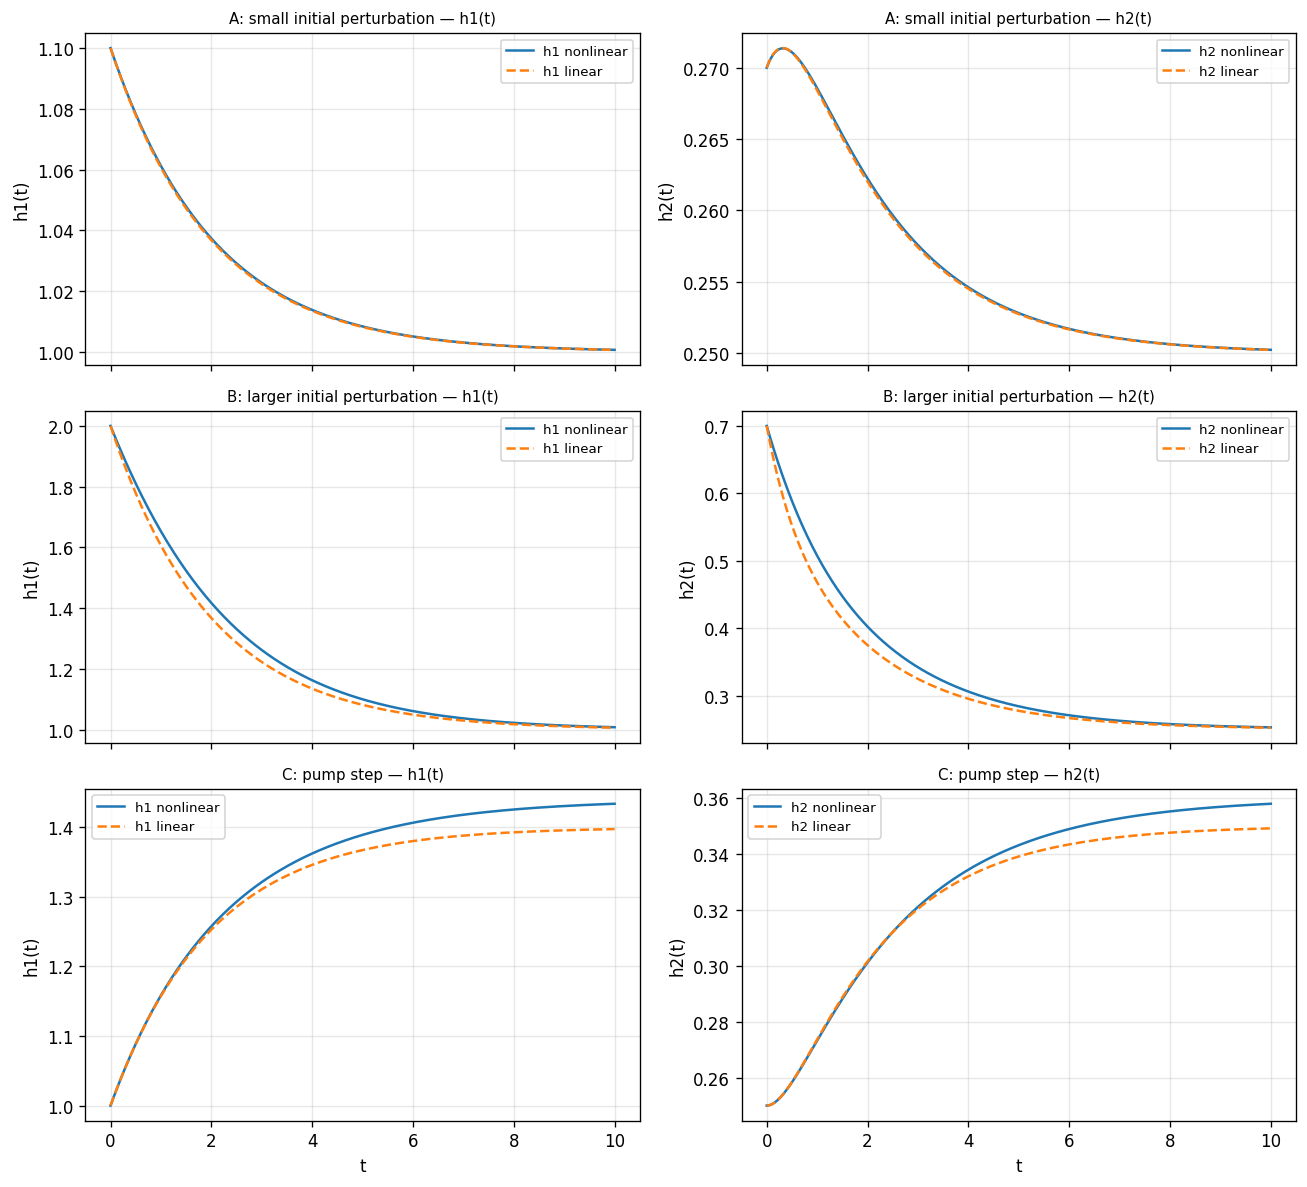

In [10]:
# Simulate Cases A–C and create the requested time-response figures.
constant_input = lambda value: (lambda t: value)

cases = {
    "A: small initial perturbation": (x_star + np.array([0.10, 0.02]), constant_input(1.0)),
    "B: larger initial perturbation": (np.array([2.00, 0.70]), constant_input(1.0)),
    "C: pump step": (x_star.copy(), constant_input(1.2)),
}

fig, axes = plt.subplots(3, 2, figsize=(11, 10), sharex=True)

for row, (name, (x0, input_function)) in enumerate(cases.items()):
    t, x_nl, x_lin = simulate_pair(x0, input_function, t_final=10.0, samples=400)

    for col, (label, idx) in enumerate([("h1", 0), ("h2", 1)]):
        ax = axes[row, col]
        ax.plot(t, x_nl[idx], "-", color="C0", label=f"{label} nonlinear")
        ax.plot(t, x_lin[idx], "--", color="C1", label=f"{label} linear")
        ax.set_ylabel(f"{label}(t)")
        ax.set_title(f"{name} — {label}(t)", fontsize=9)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
        if row == 2:
            ax.set_xlabel("t")

fig.tight_layout()
plt.show()

### Time-response interpretation

Discuss where the linear and nonlinear responses agree, where they differ, and why. For Case C, compare the final nonlinear levels with the steady levels predicted by the linear model.

The linear and nonlinear responses agree near where we linearize. As delta_h grows larger and larger things begin to disagree more and more between the linear and non-linear responses.

## Part 6 — Engineering conclusion (5 points)

In 100–150 words, give a recommendation to an engineer who wants to use the linear model for control design near the nominal operating condition. State what the model captures well, its main limitation, and what evidence from your figures supports your recommendation.

The linear model's main drawback is that it always over estimates how fast the actual system drains. This can be seen from the perturbation plots where the linear model suggests that h is lower than the non-linear model. This is the case in every plot. The model captures the overall shape of the response quite well and predicts the real response especially well with small perturbations in input from the pump or initial conditions of the tanks. In the end, the height of the fluid in each tank settles slightly higher than anticipated by the linear model. I would recommend using the linear model near the nominal point.

## Submission checklist

- [ ] I wrote the nonlinear model explicitly as $\dot x=f(t,x,u)$ and $y=g(t,x,u)$.
- [ ] Equilibrium and Jacobian calculations are shown analytically, either in the notebook or in an accompanying handwritten PDF.
- [ ] I computed $J=P^{-1}AP$ and checked whether it is diagonal.
- [ ] Every figure has a title, labeled axes, and a readable legend.
- [ ] I restarted the kernel and ran every cell in order.
- [ ] I submitted the IPYNB file and, if applicable, my handwritten analytical work as a PDF.